

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>





<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Trabalho muito sólido com o projeto! Gostei muito.
    
    
Parabéns pela aprovação e até breve!
</div>


In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from pathlib import Path

RANDOM_STATE = 12345


===== geo_data_0 =====
Shape: (100000, 5)


,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647



Tipos de dados:


id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object


Ausentes totais: 0 | Duplicatas: 0

Resumo numérico (colunas numéricas):


...

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910



Tipos de dados:


id          object
f0         float64
f1         float64
f2         float64
product    float64
dtype: object


Ausentes totais: 0 | Duplicatas: 0

Resumo numérico (colunas numéricas):


,f0,f1,f2,product
count,100000.000000,100000.000000,100000.000000,100000.000000
mean,0.002023,-0.002081,2.495128,95.000000
std,1.732045,1.730417,3.473445,44.749921
min,-8.760004,-7.084020,-11.970335,0.000000
25%,-1.162288,-1.174820,0.130359,59.450441
50%,0.009424,-0.009482,2.484236,94.925613
75%,1.158535,1.163678,4.858794,130.595027
max,7.238262,7.844801,16.739402,190.029838


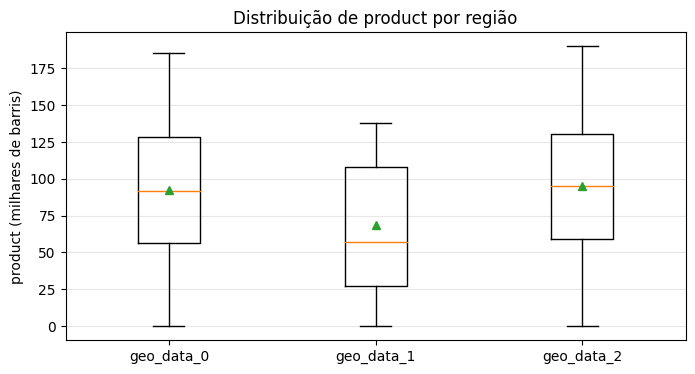

In [2]:
# Leitura dos dados (caminho identificado na sua execução: ../datasets)
DATA_DIR = Path("../datasets")

geo_0 = pd.read_csv(DATA_DIR / "geo_data_0.csv")
geo_1 = pd.read_csv(DATA_DIR / "geo_data_1.csv")
geo_2 = pd.read_csv(DATA_DIR / "geo_data_2.csv")

datasets = {
    "geo_data_0": geo_0,
    "geo_data_1": geo_1,
    "geo_data_2": geo_2
}

# Inspeção inicial
for name, df in datasets.items():
    print(f"\n===== {name} =====")
    print("Shape:", df.shape)
    display(df.head(3))  # amostra pequena para não poluir a saída
    
    # tipos e memória
    print("\nTipos de dados:")
    display(df.dtypes)
    
    # qualidade do dado
    missing = df.isna().sum()
    dup = df.duplicated().sum()
    print(f"\nAusentes totais: {int(missing.sum())} | Duplicatas: {dup}")
    
    # estatísticas só das colunas numéricas (features + alvo)
    print("\nResumo numérico (colunas numéricas):")
    display(df[["f0", "f1", "f2", "product"]].describe())

# Gráfico para visualização dos dados
product_data = [datasets[k]["product"] for k in datasets.keys()]
labels = list(datasets.keys())

plt.figure(figsize=[8, 4])
plt.boxplot(product_data, labels=labels, showmeans=True)
plt.title("Distribuição de product por região")
plt.ylabel("product (milhares de barris)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

### Inspeção inicial dos dados (geo_data_0, geo_data_1, geo_data_2)

- Cada conjunto possui **100.000 linhas e 5 colunas**: `id`, `f0`, `f1`, `f2` (features) e `product` (alvo, em **milhares de barris**).
- **Não há valores ausentes** e **não há duplicatas** em nenhuma região, portanto não foi necessário tratamento de missing values nem remoção de registros duplicados.
- Tipos de dados:
  - `id` é um identificador (`object`) e **não será utilizado como feature**.
  - `f0`, `f1`, `f2` e `product` são numéricos (`float64`).
- As médias do alvo (`product`) variam entre regiões, indicando diferentes níveis de produtividade média:
  - **Região 0:** ≈ 92,5 | **Região 1:** ≈ 68,8 | **Região 2:** ≈ 95,0
- O boxplot de `product` por região reforça visualmente essas diferenças de distribuição (mediana e dispersão), o que é relevante porque a decisão final depende do retorno esperado após seleção dos melhores poços.
- Como será usado **Regressão Linear** e as escalas/variabilidade das features diferem entre regiões, será aplicada uma **padronização (StandardScaler)** dentro de um `Pipeline`, garantindo consistência e evitando vazamento de dados entre treino e validação.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho checando a consistência dos dados.

Sempre importante para garantir uma análise robusta!
</div>




geo_data_0 | média prevista: 92.59 | RMSE: 37.58
geo_data_1 | média prevista: 68.73 | RMSE: 0.89
geo_data_2 | média prevista: 94.97 | RMSE: 40.03


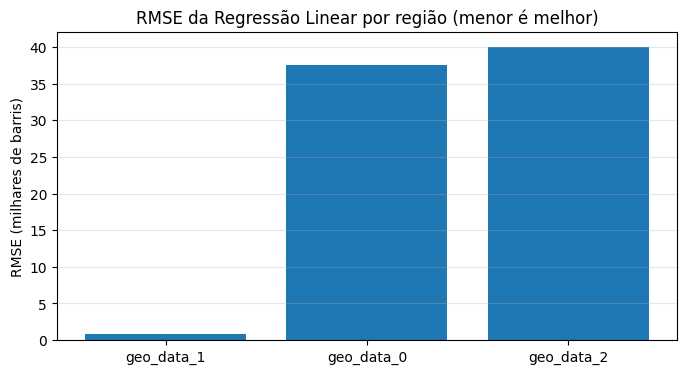

In [3]:
def train_validate_region(df, target_col="product", test_size=0.25, random_state=RANDOM_STATE):
    """
    Divide os dados (75:25), treina Regressão Linear (com padronização via Pipeline),
    gera predições no conjunto de validação e calcula RMSE e média prevista.
    Retorna também y_valid e y_pred para uso nas etapas de lucro/bootstrapping.
    """
    X = df[["f0", "f1", "f2"]]
    y = df[target_col]

    X_train, X_valid, y_train, y_valid = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LinearRegression())
    ])

    model.fit(X_train, y_train)
    y_pred = pd.Series(model.predict(X_valid), index=y_valid.index)

    rmse = mean_squared_error(y_valid, y_pred, squared=False)
    mean_pred = y_pred.mean()

    return {
        "model": model,
        "rmse": rmse,
        "mean_pred": mean_pred,
        "y_valid": y_valid,
        "y_pred": y_pred
    }

results = {}
for name, df in datasets.items():
    results[name] = train_validate_region(df)
    print(f"{name} | média prevista: {results[name]['mean_pred']:.2f} | RMSE: {results[name]['rmse']:.2f}")

# Gráfico para visualização do RMSE de cada região
rmse_df = pd.DataFrame({
    "regiao": list(results.keys()),
    "rmse": [results[k]["rmse"] for k in results.keys()]
}).sort_values("rmse", ascending=True)

plt.figure(figsize=[8, 4])
plt.bar(rmse_df["regiao"], rmse_df["rmse"])
plt.title("RMSE da Regressão Linear por região (menor é melhor)")
plt.ylabel("RMSE (milhares de barris)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

### Avaliação do modelo (Regressão Linear) por região

A Regressão Linear foi treinada em cada região com divisão **75:25** (treino:validação) e padronização das features via `StandardScaler` em `Pipeline`. Avaliamos com **RMSE** e também verificamos a **média prevista** de `product` no conjunto de validação.

**Resultados obtidos:**
- **geo_data_0:** média prevista ≈ 92,59 | **RMSE ≈ 37,58**
- **geo_data_1:** média prevista ≈ 68,73 | **RMSE ≈ 0,89**
- **geo_data_2:** média prevista ≈ 94,97 | **RMSE ≈ 40,03**

**Interpretação:**
- O gráfico de RMSE evidencia que **geo_data_1** possui erro muito menor, indicando previsões significativamente mais estáveis e consistentes nessa região.
- Já **geo_data_0** e **geo_data_2** apresentam RMSE elevado, o que sugere maior incerteza ao usar as predições para selecionar poços.
- Apesar de RMSE ser um indicador importante, a decisão de negócio será tomada com base em **lucro esperado** e **risco de prejuízo**, avaliados nas etapas seguintes.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Muito bom, modelos treinados adequadamente com métricas em linha ao esperado.
</div>




In [4]:
# Variáveis de negócio (conforme enunciado)
BUDGET_TOTAL = 100_000_000      # orçamento total para 200 poços (US$)
N_WELLS_STUDY = 500             # pontos avaliados no estudo
N_WELLS_SELECT = 200            # melhores pontos selecionados
REVENUE_PER_UNIT = 4_500        # receita por unidade de produto (mil barris) em US$

# Cálculo do break-even em unidades de produto (milhares de barris)
budget_per_well = BUDGET_TOTAL / N_WELLS_SELECT
break_even_units = budget_per_well / REVENUE_PER_UNIT

print(f"Orçamento por poço: ${budget_per_well:,.0f}")
print(f"Break-even (unidades de produto por poço): {break_even_units:.2f} (milhares de barris)")

# Comparação com a média real de product por região
region_means = pd.DataFrame({
    "regiao": list(datasets.keys()),
    "media_real_product": [df["product"].mean() for df in datasets.values()]
})

region_means["break_even_units"] = break_even_units
region_means["acima_break_even_media"] = region_means["media_real_product"] >= break_even_units

region_means

Orçamento por poço: $500,000
Break-even (unidades de produto por poço): 111.11 (milhares de barris)


,regiao,media_real_product,break_even_units,acima_break_even_media
0,geo_data_0,92.500,111.111111,False
1,geo_data_1,68.825,111.111111,False
2,geo_data_2,95.000,111.111111,False


### Preparação para o cálculo de lucro (break-even)

- O orçamento total é de **100 milhões de dólares** para desenvolver **200 poços**, o que implica **500.000 dólares por poço**.
- Cada unidade de `product` representa **1.000 barris**, e cada barril gera **4,5 dólares**. Logo, cada unidade de `product` gera **4.500 dólares** de receita.
- Assim, para não haver prejuízo, cada poço precisa produzir, em média, pelo menos:

  **break-even = 111,11 unidades** (≈ **111,11 mil barris por poço**).

- Ao comparar o break-even com o `product` médio de cada região, observamos se, em média, a região está acima ou abaixo do ponto de equilíbrio.
- Entretanto, a decisão do projeto **não é baseada na média geral**: na prática, serão escolhidos os **200 melhores poços dentre 500 avaliados** com base nas predições do modelo.
- Portanto, mesmo regiões com média geral abaixo do break-even podem se tornar viáveis caso o processo de seleção (predições + top 200) concentre poços suficientemente produtivos.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Bom trabalho com o cálculo de de breakeven.
</div>




,regiao,volume_total_real_top200,lucro_top200
0,geo_data_0,29601.835651,3.320826e+07
2,geo_data_2,28245.222141,2.710350e+07
1,geo_data_1,27589.081548,2.415087e+07


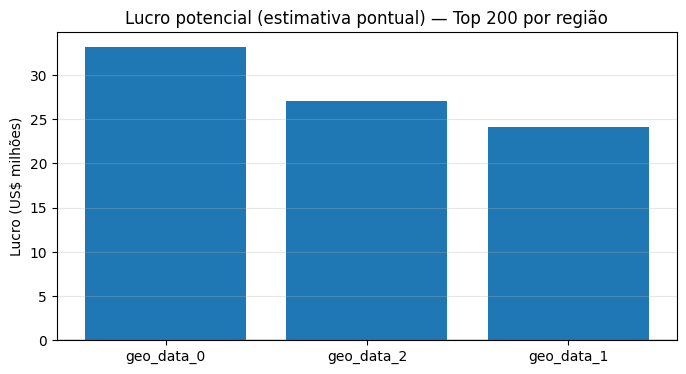

In [5]:
def calc_profit(y_true, y_pred, n_select=N_WELLS_SELECT,
                revenue_per_unit=REVENUE_PER_UNIT, budget_total=BUDGET_TOTAL):
    """
    Seleciona os n_select poços com maior y_pred e calcula o lucro usando y_true desses poços.
    Retorna:
    - lucro (US$)
    - soma do volume real (product) selecionado (milhares de barris)
    """
    top_idx = y_pred.sort_values(ascending=False).head(n_select).index
    total_product = y_true.loc[top_idx].sum()  # milhares de barris
    revenue = total_product * revenue_per_unit
    profit = revenue - budget_total
    return float(profit), float(total_product)


top200_preds = {}   # predições dos 200 melhores por região (para etapa 5)
profits_top200 = []

for name, r in results.items():
    y_valid = r["y_valid"]
    y_pred = r["y_pred"]

    # Armazenar as predições dos top 200 (por região)
    top200_preds[name] = y_pred.sort_values(ascending=False).head(N_WELLS_SELECT)

    # Lucro pontual usando os 200 melhores (seleção por y_pred, lucro por y_true)
    profit, total_product = calc_profit(y_valid, y_pred)

    profits_top200.append({
        "regiao": name,
        "volume_total_real_top200": total_product,
        "lucro_top200": profit
    })

profits_top200_df = pd.DataFrame(profits_top200).sort_values("lucro_top200", ascending=False)

# Exibir tabela (valores exatos)
display(profits_top200_df)

# Gráfico: converter lucro para US$ milhões (melhor legibilidade)
plot_df = profits_top200_df.copy()
plot_df["lucro_milhoes"] = plot_df["lucro_top200"] / 1e6

plt.figure(figsize=[8, 4])
plt.bar(plot_df["regiao"], plot_df["lucro_milhoes"])
plt.axhline(0, linewidth=1)
plt.title("Lucro potencial (estimativa pontual) — Top 200 por região")
plt.ylabel("Lucro (US$ milhões)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

### Lucro potencial (estimativa pontual) ao selecionar os 200 melhores poços

- Para cada região, selecionamos os **200 poços com maior valor previsto** (`y_pred`) no conjunto de validação.
- Em seguida, calculamos a receita usando o **volume real** (`y_true`) desses poços e subtraímos o orçamento fixo de **US$ 100 milhões**.
- A tabela e o gráfico de lucro pontual resumem o resultado desse procedimento, permitindo comparar rapidamente o retorno potencial sob a estratégia de seleção pelos maiores valores previstos.

**Observação importante:** esta estimativa é **pontual** e não mede incerteza/riscos.  
A decisão final deve considerar a distribuição de lucros e o **risco de prejuízo** via **bootstrapping** , mantendo apenas regiões com risco < 2,5%.

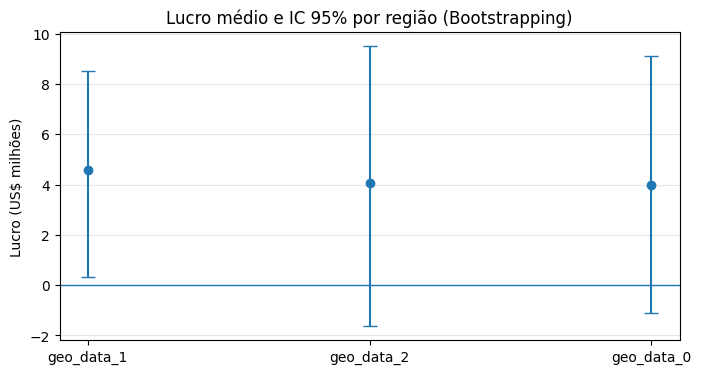

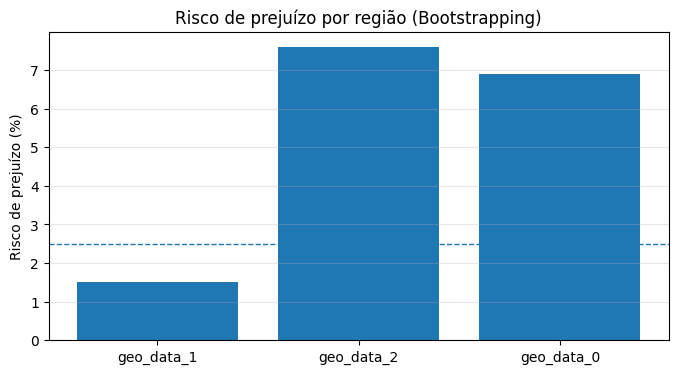

In [6]:
def bootstrap_profit_distribution(y_true, y_pred, n_bootstrap=1000,
                                  n_study=N_WELLS_STUDY, n_select=N_WELLS_SELECT,
                                  revenue_per_unit=REVENUE_PER_UNIT, budget_total=BUDGET_TOTAL,
                                  random_state=RANDOM_STATE):
    """
    Bootstrapping do processo de negócio:
    - amostra (com reposição) n_study pontos
    - seleciona os n_select maiores y_pred dentro dessa amostra
    - calcula lucro usando y_true desses selecionados
    Retorna série de lucros e métricas: média, IC95% e risco de prejuízo.
    """
    rng = np.random.RandomState(random_state)
    profits = []

    for _ in range(n_bootstrap):
        sample_idx = rng.choice(y_true.index, size=n_study, replace=True)

        sample_true = y_true.loc[sample_idx].reset_index(drop=True)
        sample_pred = y_pred.loc[sample_idx].reset_index(drop=True)

        top_idx = sample_pred.sort_values(ascending=False).head(n_select).index
        total_product = sample_true.loc[top_idx].sum()

        revenue = total_product * revenue_per_unit
        profit = revenue - budget_total
        profits.append(profit)

    profits = pd.Series(profits)

    mean_profit = profits.mean()
    ci_low, ci_high = np.percentile(profits, [2.5, 97.5])
    risk_loss = (profits < 0).mean() * 100  # %

    return profits, float(mean_profit), float(ci_low), float(ci_high), float(risk_loss)


bootstrap_rows = []
bootstrap_profits = {}

for name, r in results.items():
    profits, mean_profit, ci_low, ci_high, risk_loss = bootstrap_profit_distribution(
        r["y_valid"], r["y_pred"], n_bootstrap=1000
    )

    bootstrap_profits[name] = profits

    bootstrap_rows.append({
        "regiao": name,
        "lucro_medio": mean_profit,
        "ic_95_low": ci_low,
        "ic_95_high": ci_high,
        "risco_prejuizo_%": risk_loss
    })

bootstrap_df = pd.DataFrame(bootstrap_rows).sort_values("lucro_medio", ascending=False)
bootstrap_df

# 1) Lucro médio com IC 95%
plot_df = bootstrap_df.copy()
plot_df["lucro_medio_m"] = plot_df["lucro_medio"] / 1e6
plot_df["ic_95_low_m"] = plot_df["ic_95_low"] / 1e6
plot_df["ic_95_high_m"] = plot_df["ic_95_high"] / 1e6

y = plot_df["lucro_medio_m"].values
yerr = np.vstack([y - plot_df["ic_95_low_m"].values, plot_df["ic_95_high_m"].values - y])

plt.figure(figsize=[8, 4])
plt.errorbar(plot_df["regiao"], y, yerr=yerr, fmt="o", capsize=5)
plt.axhline(0, linewidth=1)
plt.title("Lucro médio e IC 95% por região (Bootstrapping)")
plt.ylabel("Lucro (US$ milhões)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

# 2) Risco de prejuízo com linha de corte 2,5%
plt.figure(figsize=[8, 4])
plt.bar(plot_df["regiao"], plot_df["risco_prejuizo_%"])
plt.axhline(2.5, linestyle="--", linewidth=1)
plt.title("Risco de prejuízo por região (Bootstrapping)")
plt.ylabel("Risco de prejuízo (%)")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


### Bootstrapping: lucro médio, IC 95% e risco de prejuízo

Foi aplicado bootstrapping com **1.000 amostras** para simular o processo de decisão:
1. Amostrar (com reposição) **500 poços** para estudo;
2. Selecionar os **200 melhores** com base nas predições do modelo;
3. Calcular o lucro usando o volume real desses 200 poços.

Para cada região, foi estimado:
- **Lucro médio**
- **Intervalo de confiança de 95% (IC 95%)**
- **Risco de prejuízo**: proporção de amostras com lucro < 0 (em %)

Os gráficos de (i) **lucro médio com IC 95%** e (ii) **risco de prejuízo com linha de corte de 2,5%** sintetizam o trade-off entre retorno e risco por região.

**Critério de decisão (negócio):**
- Manter apenas regiões com **risco de prejuízo < 2,5%**
- Entre as elegíveis, escolher a região com **maior lucro médio**

Com base nos resultados, **geo_data_1** é a única região que atende ao critério de risco (< 2,5%) e, portanto, é a recomendação final, mesmo que a estimativa pontual da etapa anterior tenha favorecido outra região.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Perfeito o trabalho. Toda a etapa de bootstrap foi realizada utilizando os modelos adequadas e atendendo os parâmetros solicitados.

As conclusões de lucro e prejuízo estão em linha ao esperado. Excelente!
</div>




## Conclusão final

Neste projeto, foram construídos modelos de **Regressão Linear** (com padronização via `StandardScaler` em `Pipeline`) para prever `product` (volume de reservas em milhares de barris) em três regiões, seguindo as condições de negócio: estudo de **500 poços**, seleção dos **200 melhores**, orçamento total de **100 milhões de dólares** e receita de **4.500 dólares por unidade** de `product`.

### Desempenho do modelo
Os resultados de validação mostraram diferenças relevantes de precisão entre regiões:
- **geo_data_1** apresentou **RMSE muito baixo (≈ 0,89)**, indicando previsões significativamente mais estáveis.
- **geo_data_0** e **geo_data_2** apresentaram **RMSE elevado (≈ 37–40)**, sugerindo maior incerteza ao usar as predições para selecionar poços.

### Viabilidade econômica (break-even)
O custo por poço é de **500.000 dólares**. Para não haver prejuízo, cada poço precisa produzir, em média, pelo menos **111,11 unidades** de `product` (≈ 111,11 mil barris). As médias de `product` nas três regiões ficaram abaixo desse valor, reforçando que a decisão deve se basear na estratégia de seleção dos melhores poços (top 200) e na avaliação de risco.

### Lucro potencial (estimativa pontual – Top 200)
Ao selecionar os **200 poços com maior valor previsto** em cada região e calcular o lucro com o volume real desses poços, foi obtida uma estimativa pontual na qual a **geo_data_0** teve o maior lucro (≈ 33,21 milhões), seguida de **geo_data_2** (≈ 27,10 milhões) e **geo_data_1** (≈ 24,15 milhões).  
No entanto, esta estimativa não quantifica a incerteza nem o risco de prejuízo.

### Bootstrapping (decisão final sob risco)
Foi aplicado o **bootstrapping com 1.000 amostras** para simular o processo real de decisão (amostrar 500 → selecionar 200 → calcular lucro). Os resultados foram:

- **geo_data_1**: lucro médio ≈ **4,56 milhões**, IC 95% ≈ **[0,34; 8,52] milhões**, risco de prejuízo ≈ **1,5%**
- **geo_data_2**: lucro médio ≈ **4,04 milhões**, IC 95% ≈ **[-1,63; 9,50] milhões**, risco de prejuízo ≈ **7,6%**
- **geo_data_0**: lucro médio ≈ **3,96 milhões**, IC 95% ≈ **[-1,11; 9,10] milhões**, risco de prejuízo ≈ **6,9%**

Pelo critério do enunciado, foram mantidas apenas regiões com **risco de prejuízo < 2,5%**. Assim, **geo_data_1** é a única região elegível e, portanto, é a **recomendação final** para desenvolvimento dos novos poços.

### Comparação com a etapa anterior
A recomendação final **não coincide** com a estimativa pontual da etapa 4 (que favorecia geo_data_0), porque o bootstrapping incorpora a variabilidade do processo (500→200) e evidencia que geo_data_0 e geo_data_2 apresentam risco de prejuízo acima do limite, enquanto geo_data_1 combina **maior previsibilidade** (RMSE muito baixo) com **risco aceitável**.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Conclusão apresentada!
</div>
